# 02 — Model Development

This notebook covers:
1. Baseline model (Logistic Regression)
2. Random Forest
3. XGBoost with class-imbalance handling
4. Hyperparameter tuning (RandomizedSearchCV)
5. Feature importance
6. Final evaluation on the test set

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

from src.data_preprocessing import load_data, preprocess
from src.features import build_features

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load & Prepare Data

In [2]:
df = load_data('../data/churn.csv')
df = preprocess(df)
df = build_features(df)

TARGET = 'churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features: {list(X.columns)}')
print(f'Class balance:\n{y.value_counts()}')

Features: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'balance_salary_ratio', 'age_group', 'zero_balance']
Class balance:
churn
0    7963
1    2037
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (8000, 13)  |  Test: (2000, 13)


## 2. Baseline — Logistic Regression

In [4]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)

print('=== Logistic Regression ===')
print(classification_report(y_test, lr.predict(X_test_s)))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_s)[:,1]):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1593
           1       0.38      0.72      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000

ROC-AUC: 0.7724


## 3. Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_s, y_train)

print('=== Random Forest ===')
print(classification_report(y_test, rf.predict(X_test_s)))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test_s)[:,1]):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1593
           1       0.77      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC: 0.8511


## 4. XGBoost with Class-Imbalance Handling

In [6]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss', random_state=RANDOM_STATE
)
xgb.fit(X_train_s, y_train)

print('=== XGBoost ===')
print(classification_report(y_test, xgb.predict(X_test_s)))
print(f'ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test_s)[:,1]):.4f}')

scale_pos_weight = 3.91
=== XGBoost ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.51      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC: 0.8603


## 5. Hyperparameter Tuning (RandomizedSearchCV)

In [7]:
param_dist = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
search.fit(X_train_s, y_train)

print(f'Best params: {search.best_params_}')
print(f'Best CV ROC-AUC: {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV ROC-AUC: 0.8634


In [8]:
best = search.best_estimator_
print('=== Tuned XGBoost ===')
print(classification_report(y_test, best.predict(X_test_s)))
print(f'ROC-AUC: {roc_auc_score(y_test, best.predict_proba(X_test_s)[:,1]):.4f}')

=== Tuned XGBoost ===
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.50      0.77      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.81      2000

ROC-AUC: 0.8652


## 6. Feature Importance

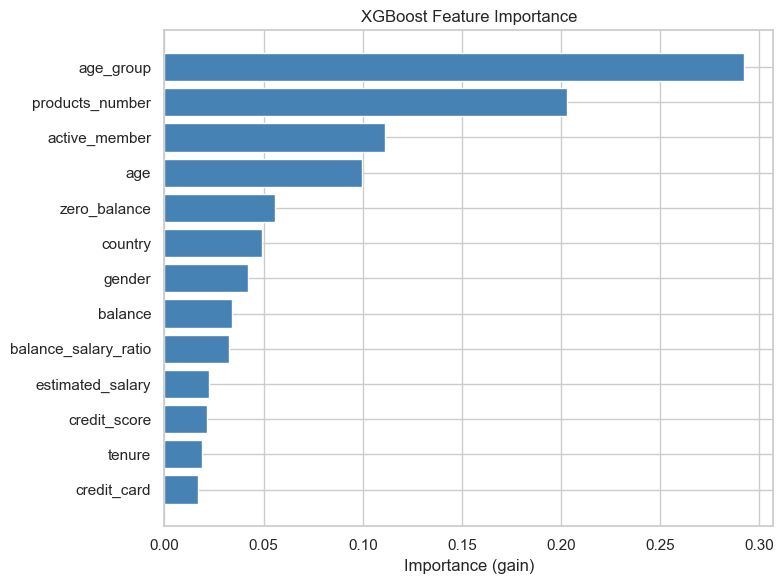

In [9]:
feature_names = list(X.columns)
importances   = best.feature_importances_
indices       = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feature_names[i] for i in indices], importances[indices], color='steelblue')
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 7. Final Evaluation Plots

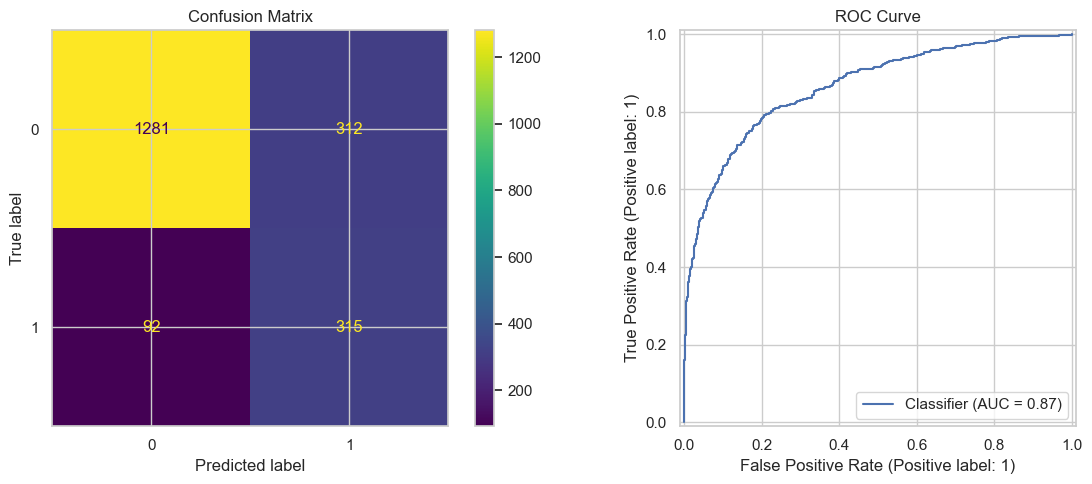

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, best.predict(X_test_s), ax=axes[0])
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, best.predict_proba(X_test_s)[:,1], ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

## 8. Model Comparison Summary

In [11]:
models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'XGBoost (tuned)':     best,
}

rows = []
for name, m in models.items():
    y_pred = m.predict(X_test_s)
    y_prob = m.predict_proba(X_test_s)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    rows.append({
        'Model':     name,
        'Accuracy':  round(report['accuracy'], 4),
        'Precision (churn)': round(report['1']['precision'], 4),
        'Recall (churn)':    round(report['1']['recall'], 4),
        'F1 (churn)':        round(report['1']['f1-score'], 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    })

pd.DataFrame(rows).set_index('Model')

,Accuracy,Precision (churn),Recall (churn),F1 (churn),ROC-AUC
Model,,,,,
Logistic Regression,0.7070,0.3830,0.7199,0.5000,0.7724
Random Forest,0.8565,0.7679,0.4226,0.5452,0.8511
XGBoost,0.8050,0.5145,0.7420,0.6076,0.8603
XGBoost (tuned),0.7980,0.5024,0.7740,0.6093,0.8652
